# Healthcare Appointment No-Show Prediction

## End-to-End Data Science Case Study

This notebook demonstrates a full Data Science workflow including business understanding, data quality assessment, feature engineering, statistical testing, machine learning, model evaluation, explainability, and business recommendations.

## 1. Business Understanding

### Problem
Missed healthcare appointments reduce care quality, increase costs, and create scheduling inefficiencies.

### Goal
Predict which patients are likely to miss appointments and identify actionable drivers of no-show behavior.

### Success Metrics
- ROC-AUC
- Precision
- Recall
- Business usefulness of recommendations

Import the Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay

)

In [2]:
df = pd.read_csv(r"C:\Users\austi\anaconda3\KaggleV2-May-2016.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


Use these functions to understand the dataset before starting the modeling

In [6]:
df.shape


(110527, 14)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [8]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


Check for missing values, duplicates and suspicious records

In [9]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df[df['Age'] < 0] 

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99832,4.659432e+14,5775010,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1,ROMÃO,0,0,0,0,0,0,No


Convert the dates


In [12]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

Feature Engineering

- Feature Engineering often contributes more performance than changing Algorithms.

In [32]:
df['DaysWaiting'] = (
    pd.to_datetime(df['AppointmentDay'].dt.date) - pd.to_datetime(df['ScheduledDay'].dt.date)
).dt.days

df = df[df['DaysWaiting'] >= 0]

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins= [0,18,35,50,65,120],
    labels= ['Child','YoungAdult','Adult','MiddleAge','Senior']
)

df['HealthRiskScore'] = (
    df['Hipertension'] + df['Diabetes'] + df['Alcoholism'] + df['Handcap']
)

df['AppointmentWeekday'] = (
    df['AppointmentDay'].dt.day_name()
)

df['SameDayAppointment'] = (df['DaysWaiting'] == 0).astype(int)
df['LongWait'] = (df['DaysWaiting'] > 14).astype(int)
df['HealthRiskScore'] = (df['HealthRiskScore'] >= 2).astype(int)

Exploratory Data Analysis
 
 - Understanding the patterns before modeling

In [35]:

df['No-show'].value_counts(normalize=True)

No-show
No     0.798104
Yes    0.201896
Name: proportion, dtype: float64

Age Distribution

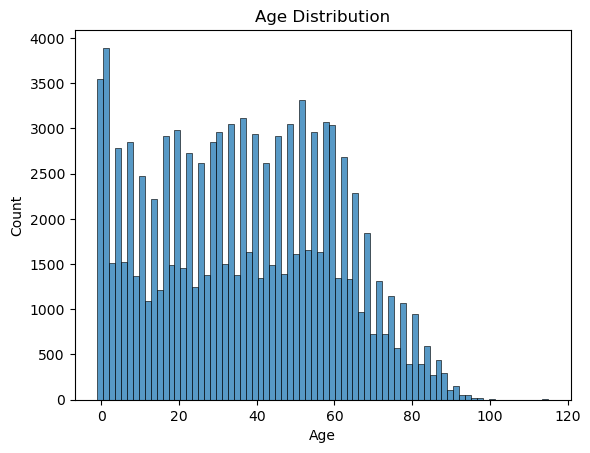

In [37]:
sns.histplot(df['Age'])
plt.title('Age Distribution')
plt.show()

SMS Reminder Analysis

In [38]:
pd.crosstab(
    df['SMS_received'], df['No-show'], normalize = 'index'
)

No-show,No,Yes
SMS_received,,
0,0.833022,0.166978
1,0.724255,0.275745


WeekDay Analysis

In [39]:
pd.crosstab(
    df['AppointmentWeekday'], df['No-show'], normalize = 'index'
)

No-show,No,Yes
AppointmentWeekday,,
Friday,0.787739,0.212261
Monday,0.793563,0.206437
Saturday,0.769231,0.230769
Thursday,0.806506,0.193494
Tuesday,0.799126,0.200874
Wednesday,0.803139,0.196861


Correlation Heatmap


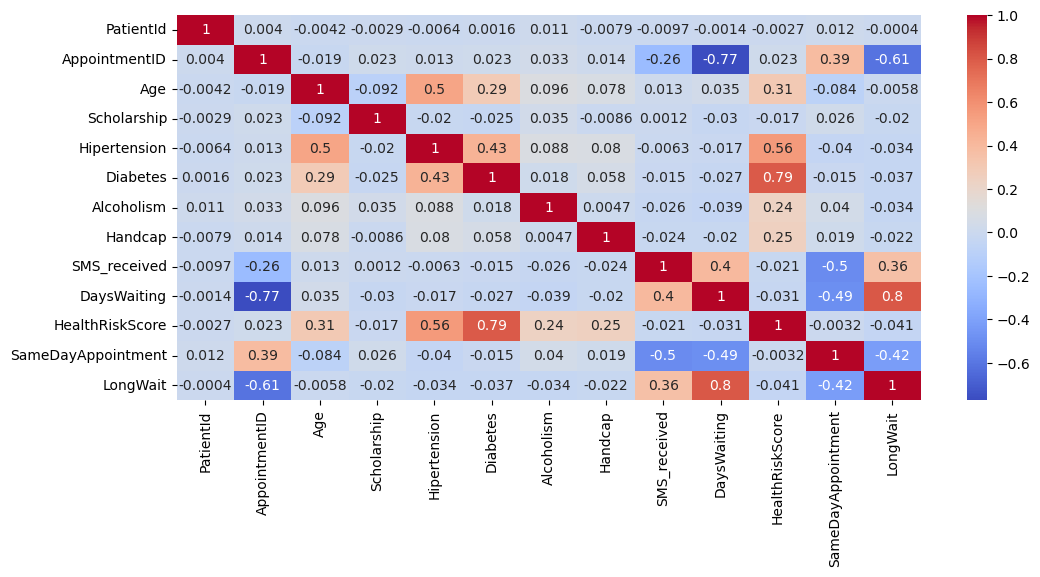

In [43]:
plt.figure(figsize=(12,5))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

Statistical Testing 

- Determine whether the waiting time differs significantly between groups.

In [44]:
show = df[df['No-show'] == "No"]['DaysWaiting']
noshow = df[df['No-show'] == "Yes"]['DaysWaiting']

t,p = ttest_ind(show,noshow)

print('Tstatistic: ', t)
print('P Value: ', p)

Tstatistic:  -63.04594591751336
P Value:  0.0


Modeling Dataset preparation

In [47]:
model_df = df.copy()
model_df = model_df.drop(
    columns=[
        'PatientId',
        'AppointmentID',
        'ScheduledDay',
        'AppointmentDay'
    ]
)

model_df = pd.get_dummies(
    model_df,
    drop_first= True
)



,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,DaysWaiting,HealthRiskScore,SameDayAppointment,...,No-show_Yes,AgeGroup_YoungAdult,AgeGroup_Adult,AgeGroup_MiddleAge,AgeGroup_Senior,AppointmentWeekday_Monday,AppointmentWeekday_Saturday,AppointmentWeekday_Thursday,AppointmentWeekday_Tuesday,AppointmentWeekday_Wednesday
0,62,0,1,0,0,0,0,0,0,1,...,False,False,False,True,False,False,False,False,False,False
1,56,0,0,0,0,0,0,0,0,1,...,False,False,False,True,False,False,False,False,False,False
2,62,0,0,0,0,0,0,0,0,1,...,False,False,False,True,False,False,False,False,False,False
3,8,0,0,0,0,0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,False
4,56,0,1,1,0,0,0,0,1,1,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,56,0,0,0,0,0,1,35,0,0,...,False,False,False,True,False,False,False,False,True,False
110523,51,0,0,0,0,0,1,35,0,0,...,False,False,False,True,False,False,False,False,True,False
110524,21,0,0,0,0,0,1,41,0,0,...,False,True,False,False,False,False,False,False,True,False
110525,38,0,0,0,0,0,1,41,0,0,...,False,False,True,False,False,False,False,False,True,False


Train Test Split

In [51]:
X = model_df.drop(columns=['No-show_Yes'])

y = model_df['No-show_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=.20,
    random_state=42,
    stratify=y
)

Baseline Model

- Always compare against a simple baseline

In [52]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train,y_train)
dummy_pred = dummy.predict(X_test)
print(classification_report(y_test,dummy_pred))

              precision    recall  f1-score   support

       False       0.80      1.00      0.89     17642
        True       0.00      0.00      0.00      4463

    accuracy                           0.80     22105
   macro avg       0.40      0.50      0.44     22105
weighted avg       0.64      0.80      0.71     22105



c:\Users\austi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\austi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\austi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logistic Regression Model

- Provides an interpretable baseline Model.

In [53]:
lr = LogisticRegression(max_iter=2000)

lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)

print(classification_report(y_test,lr_pred))

lr_auc = roc_auc_score(
    y_test,
    lr.predict_log_proba(X_test)[:,1]
)

print('ROC-AUC: ', lr_auc)

              precision    recall  f1-score   support

       False       0.80      1.00      0.89     17642
        True       0.51      0.00      0.01      4463

    accuracy                           0.80     22105
   macro avg       0.66      0.50      0.45     22105
weighted avg       0.74      0.80      0.71     22105

ROC-AUC:  0.7205244456282562


In [54]:
lr = LogisticRegression(max_iter=2000, class_weight='balanced')

lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)

print(classification_report(y_test,lr_pred))

lr_auc = roc_auc_score(
    y_test,
    lr.predict_log_proba(X_test)[:,1]
)

print('ROC-AUC: ', lr_auc)

              precision    recall  f1-score   support

       False       0.92      0.52      0.66     17642
        True       0.30      0.83      0.44      4463

    accuracy                           0.58     22105
   macro avg       0.61      0.67      0.55     22105
weighted avg       0.80      0.58      0.62     22105

ROC-AUC:  0.7198100605406055


Run a Confusion Matrix


In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    lr_pred
)

print(cm)

[[9099 8543]
 [ 744 3719]]


In [57]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

       False       0.82      0.92      0.87     17642
        True       0.41      0.21      0.28      4463

    accuracy                           0.78     22105
   macro avg       0.61      0.57      0.57     22105
weighted avg       0.74      0.78      0.75     22105



In [58]:
rf_probs = rf.predict_proba(X_test)[:,1]

rf_auc = roc_auc_score(
    y_test,
    rf_probs
)

print(rf_auc)

0.7226301975331667


In [61]:
from xgboost import XGBClassifier

In [62]:
print(y_train.value_counts())

No-show_Yes
False    70566
True     17851
Name: count, dtype: int64


In [63]:
negative = y_train.value_counts()[0]
positive = y_train.value_counts()[1]

scale_pos_weight = negative / positive

print(scale_pos_weight)

3.953055851212817


C:\Users\austi\AppData\Local\Temp\ipykernel_28464\2552991607.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  negative = y_train.value_counts()[0]
C:\Users\austi\AppData\Local\Temp\ipykernel_28464\2552991607.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  positive = y_train.value_counts()[1]


In [64]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [65]:
xgb_pred = xgb.predict(X_test)

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

       False       0.92      0.54      0.68     17642
        True       0.31      0.81      0.45      4463

    accuracy                           0.60     22105
   macro avg       0.62      0.68      0.57     22105
weighted avg       0.80      0.60      0.64     22105



In [66]:
xgb_probs = xgb.predict_proba(X_test)[:,1]

xgb_auc = roc_auc_score(
    y_test,
    xgb_probs
)

print("ROC-AUC:", xgb_auc)

ROC-AUC: 0.7363952111712311


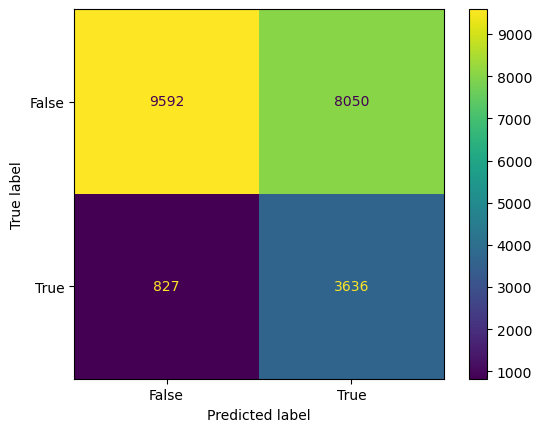

In [67]:
ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_test,
    y_test
)

plt.show()

In [68]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
9,SameDayAppointment,0.250762
7,DaysWaiting,0.060145
10,LongWait,0.026633
81,Neighbourhood_SANTOS DUMONT,0.019858
6,SMS_received,0.013289
0,Age,0.011651
16,Neighbourhood_BELA VISTA,0.011536
88,Neighbourhood_SÃO PEDRO,0.010927
87,Neighbourhood_SÃO JOSÉ,0.010911
47,Neighbourhood_ITARARÉ,0.010538


## Model Evaluation Summary

Healthcare Appointment No-Show Prediction


Healthcare organizations experience significant operational and financial challenges when patients fail to attend scheduled appointments. The objective of this project was to identify factors associated with appointment no-shows and develop predictive models capable of identifying high-risk patients before missed appointments occur.

Using a dataset containing over 110,000 healthcare appointments, I performed data quality assessment, feature engineering, exploratory data analysis, statistical hypothesis testing, and machine learning modeling. Several classification algorithms were evaluated, including Logistic Regression, Random Forest, and XGBoost. To address class imbalance, class-weighting techniques were implemented to improve identification of no-show patients.

The final XGBoost model achieved a ROC-AUC of 0.736 and an 81% recall rate for identifying patients at risk of missing appointments. Statistical testing demonstrated that appointment wait times were significantly associated with attendance outcomes (p < 0.001). Feature importance analysis revealed that same-day appointment scheduling was the strongest predictor of attendance behavior, followed by appointment wait time, long-wait indicators, SMS reminders, and patient demographics.

Based on these findings, recommendations included expanding same-day appointment availability, reducing appointment wait times, implementing targeted outreach for high-risk patients, and optimizing reminder strategies to improve attendance and healthcare resource utilization.



